# MViT


<font color="red">**0 前言**</font><br>
&nbsp;&nbsp;&nbsp;&nbsp;0.1 为什么需要MViT？<br>
&nbsp;&nbsp;&nbsp;&nbsp;0.2 MViT想解决ViT的什么问题？<br>

<font color="red">**1 MViT的核心思想与整体结构**</font><br>
&nbsp;&nbsp;&nbsp;&nbsp;1.1 什么叫多尺度Transformer？<br>
&nbsp;&nbsp;&nbsp;&nbsp;1.2 MViT整体结构与数据流<br>
&nbsp;&nbsp;&nbsp;&nbsp;1.3 MViT和ViT的关键区别<br>

**2 MViT中的尺度变化机制**<br>
&nbsp;&nbsp;&nbsp;&nbsp;2.1 为什么视觉建模需要多尺度表示？<br>
&nbsp;&nbsp;&nbsp;&nbsp;2.2 Token数量为什么要逐步减少？<br>
&nbsp;&nbsp;&nbsp;&nbsp;2.3 通道维度为什么要逐步增加？<br>

**3 MViT中的注意力是如何配合尺度变化的**<br>
&nbsp;&nbsp;&nbsp;&nbsp;3.1 Pooling Attention的基本思路<br>
&nbsp;&nbsp;&nbsp;&nbsp;3.2 下采样后注意力计算发生了什么变化？<br>
&nbsp;&nbsp;&nbsp;&nbsp;3.3 这样设计为什么更适合视觉任务？<br>

**4 MViT的特点、优势与理解要点**<br>
&nbsp;&nbsp;&nbsp;&nbsp;4.1 MViT相比ViT解决了什么问题？<br>
&nbsp;&nbsp;&nbsp;&nbsp;4.2 MViT和CNN在多尺度思想上有什么相似与不同？<br>
&nbsp;&nbsp;&nbsp;&nbsp;4.3 学习MViT时最容易混淆的点<br>


## 0 前言

ViT告诉我们：视觉输入也可以切成 token，再交给 Transformer 处理。

但 MViT 关心的是更难的对象：**视频**。视频是 `T × H × W` 的时空数据，token 数量比图像大得多，所以很快会遇到两个问题：

- 时空 token 太多，计算量太大
- 只在固定尺度上建模，不够适合视频这种层次很强的信号

因此，MViT的核心问题可以压成一句话：

**怎样让 Transformer 在处理视频时，也具备多尺度时空表示能力？**

后面主要看两件事：

1. 为什么视频任务需要多尺度表示。
2. MViT怎样把这种多尺度能力做进Transformer里。


### 0.1 为什么需要MViT？

原因很简单：**视频不是普通序列，而是时空层次很强的三维信号。**

做视频理解时，模型通常既要看：

- 局部外观和短时运动
- 更长时间、更大空间范围的动作语义

这意味着模型不能一直停留在同一种粒度上。更自然的做法是：

- 前层保留更细的时空分辨率
- 后层逐步聚合成更粗、更强的语义表示

这就是多尺度表示的核心直觉。MViT 的作用，就是把这种“由细到粗”的时空表示演化过程放进 Transformer 里。


### 0.2 MViT想解决ViT的什么问题？

ViT 的典型做法是：输入切成 token 以后，后面很多层都在**固定尺度**上处理它们。

这对视频来说有两个明显问题：

- token 一直很多，注意力计算太贵
- 表示缺少“前层细、后层粗”的层次变化

所以 MViT 想解决的核心问题就是：

**让时空 token 随着网络加深逐步变少，但每个 token 的表示能力逐步变强。**

也就是：

- 时空分辨率下降
- token 数量减少
- 通道维度增加

这可以把它先理解成一种“Transformer版的层次化时空特征提取”。


## 1 MViT的核心思想与整体结构

这一章只抓一条主线：

**MViT = 用 Transformer 做多尺度视频建模。**

后面主要看三件事：

- 什么叫“多尺度”
- 数据在网络里怎样流动
- 它和 ViT 的关键区别是什么


### 1.1 什么叫多尺度Transformer？

这里最容易误解的一点是：**MViT里的“多尺度”不是把同一段视频做成多个输入版本，而是让模型内部的表示随着层数加深逐步改变尺度。**

更准确地说，同一段视频进入网络后，中间表示会沿着下面这个方向演化：

- 时空分辨率逐步下降
- token 数量逐步减少
- 通道维度逐步增加

前两个变化决定“看得有多细”，第三个变化决定“每个 token 能表达多复杂的语义”。因此，MViT形成了一种很典型的结构：

- 前层：时空分辨率高，token 多，但通道较小
- 后层：时空分辨率低，token 少，但通道更大

这正好符合视频理解的需求。前层更适合保留局部外观和短时运动，后层更适合整合更大范围的时空信息，形成完整动作语义。

这里还要纠正一个常见误解：**token 变少，不等于信息简单变少。** 更准确地说，是低层的大量细粒度信息，被逐步汇聚到更少但更强的高层 token 里。

如果和原始 ViT 对比，就更容易理解了。ViT 更接近“单尺度”处理：输入切成 token 以后，后面很多层基本都在固定尺度上建模。而 MViT 强调的是：**不仅 token 的内容要更新，token 的尺度本身也要更新。**

所以，当我们说 MViT 是一个“多尺度 Transformer”时，最简洁的理解就是：

**它把 Transformer 组织成若干个不同尺度的 stage，使表示在时间、空间和通道三个维度上逐步演化。**

带着这个理解，下一节再看 MViT 的整体数据流就会顺很多。


### 1.2 MViT整体结构与数据流

这一节我们不再只说“它会逐步变成多尺度”，而是按**张量真正流过网络的顺序**来讲：从输入视频开始，到 cube embedding、到每个 stage 里的多头池化注意力，再到最后输出，看看每一步到底做了什么，输入输出尺寸怎么变。

为了统一记号，我们先约定：

- 原始输入视频记作 `3 × T × H × W`
- 其中 `3` 是 RGB 通道数
- `T` 是时间长度，`H` 和 `W` 是空间高宽
- 如果把时空位置全部展平，token 总数记作 `L = T × H × W`
- 每个 token 的通道维度记作 `C`

后面你会不断看到一个核心矛盾：**视频里的时空位置很多，所以 `L` 很大；但注意力计算又和 token 数量高度相关，所以不能让 `L` 在整个网络里一直维持不变。** MViT整套结构，本质上就是围绕这个矛盾设计出来的。

#### 1.2.1 第一步：从输入视频到初始时空 token

MViT并不会直接把原始像素展平成一长串序列。它先做的是一个类似 `patch embedding` 的操作，只不过在视频里，切分对象不再只是二维 patch，而是**时空小立方体**，论文里记作 `cube`。

如果这个时空块的尺寸是 `c_T × c_H × c_W`，步幅是 `s_T × s_H × s_W`，那么它做的事情可以理解成：

1. 在时间维上按 `c_T` 去看连续若干帧。
2. 在空间维上按 `c_H × c_W` 去看局部区域。
3. 把每个时空小块投影成一个 `C` 维向量。

这样一来，输入视频就从 `3 × T × H × W` 被改写成一组时空 token。若暂时忽略边界填充，输出分辨率大致会变成：

- 时间：`T_1 = T / s_T`
- 高度：`H_1 = H / s_H`
- 宽度：`W_1 = W / s_W`
- 通道：`C_1 = C`

因此，嵌入后的张量既可以写成：

- `C × T_1 × H_1 × W_1`

也可以在展平后写成：

- `L_1 × C`，其中 `L_1 = T_1 × H_1 × W_1`

这一步非常重要。因为从这里开始，模型处理的就不再是原始像素，而是**带有时空位置含义的 token 序列**了。

论文的 base 结构里，初始 embedding 的一个典型趋势是：

- 空间上先做比较明显的下采样
- 时间上保留得相对更多
- 通道维度先设置得比较小

也就是说，MViT宁可一开始保留较密的时空布局，也不愿一上来就把每个 token 做得很“厚”。这是因为前层更需要看清局部外观和短时动态，而不是马上做很重的高层语义压缩。


#### 1.2.2 第二步：加位置信息与 class token

时空 token 得到之后，还不能直接放心送入 Transformer。因为注意力机制本身对顺序和空间排列并不敏感，所以还需要补上位置信息。

因此，初始 token 序列会再加上位置编码。与此同时，论文也保留了一个**class token**，用于最后的视频级分类。

于是，真正进入主干之前的序列可以理解成：

- 数据 token：`L_1 × C`
- class token：`1 × C`
- 合在一起后：`(L_1 + 1) × C`

这里要特别注意一个后面会反复出现的点：**后续的时空下采样主要作用在数据 token 上，而 class token 并不会像普通时空 token 那样被一起池化掉。**

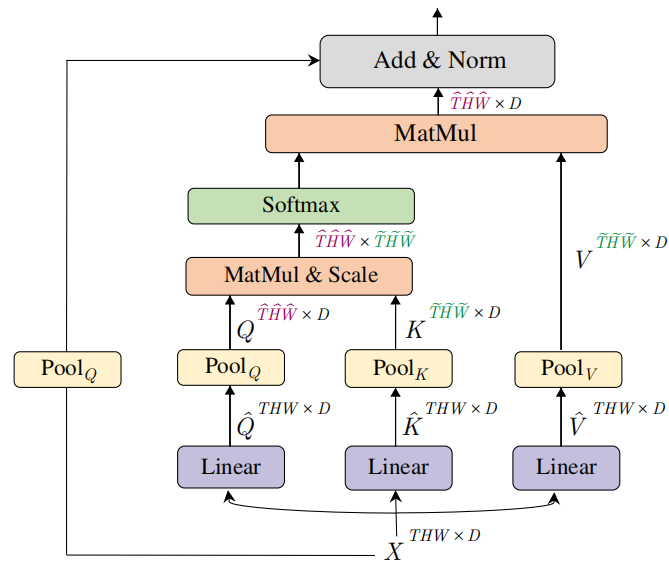

#### 1.2.3 第三步：一个 stage 内部，一个 MHPA block 是怎么走的？

接下来正式进入 MViT 的核心模块：`MHPA`，也就是 `Multi-Head Pooling Attention`，多头池化注意力。

为了先看清数据流，我们先只看一个 block。假设某个 block 的输入是：

- 展平形式：`L × C`
- 或者还原成时空形式：`C × T × H × W`

那么这个 block 大体会经历下面几步。

第一步，先做线性映射，得到 `Q、K、V`。

也就是从输入 `X` 经过三组线性层，得到：

- `Q_hat ∈ R^{L × C}`
- `K_hat ∈ R^{L × C}`
- `V_hat ∈ R^{L × C}`

如果把它们重新看成时空张量，就是：

- `C × T × H × W`

第二步，对 `Q、K、V` 分别做池化。

这正是 MViT 和普通多头注意力最关键的区别。原始 Transformer 里的注意力一般默认 `Q、K、V` 的长度都不变；但 MViT 在这里插入了池化操作，也就是论文里记作 `P(·)` 的 pooling operator。

池化后会得到：

- `Q = P(Q_hat)`
- `K = P(K_hat)`
- `V = P(V_hat)`

这一步为什么关键？因为它把“尺度变化”直接塞进了注意力本身。

更具体地说：

- **Q pooling** 决定这个 block 输出的时空分辨率
- **K/V pooling** 不改变输出分辨率，但能减少参与注意力计算的键和值的长度，从而降低计算量

也就是说，Q 更像是在回答“我最后输出多少个 token”；K/V 更像是在回答“我做注意力时，要参考多长的上下文序列”。

第三步，做多头注意力计算。

池化后的 `Q、K、V` 再进入标准注意力公式：

`Attention(Q, K, V) = Softmax(QK^T / sqrt(d))V`

其中 `d` 是每个 head 的通道维度。

如果有 `h` 个 head，那么通道会被拆成 `h` 份，每个 head 处理 `C / h` 维，再在最后拼回来。因此，一个 MHPA block 的输出仍然是某种“序列 × 通道”的结构，只不过它的**序列长度可能已经因为 Q pooling 发生了变化**。

第四步，残差连接与 MLP。

注意这里有一个很容易忽略的细节：如果这个 block 做了下采样，那么输入和输出的序列长度就不一样了，残差连接没法直接相加。所以论文专门提到：

- 当 Q 被池化时，残差支路上的输入也要做对应池化
- 当通道维度要变化时，还要补一层线性投影来对齐通道数

之后再经过 `LN + MLP`。其中 MLP 不只是普通的非线性变换，在 stage 切换前后，它还承担了**通道扩展**的角色。

所以，一个 block 的数据流如果用最简化的话概括，就是：

`输入 X -> 线性映射成 Q/K/V -> 对 Q/K/V 做池化 -> 多头注意力 -> 残差对齐 -> MLP -> 输出`

#### 1.2.4 第四步：多个 stage 之间，尺寸到底怎么变？

理解了一个 block 之后，再看整个网络就清楚多了。MViT不是让所有 block 都在同一个尺度上工作，而是把网络分成多个 stage。同一 stage 内部，尺度大体保持稳定；进入下一 stage 的开头时，再做一次比较明确的分辨率变化。

以论文表 2 的 base 结构为例，如果把初始 embedding 后的输出记成：

- `C = D`
- 时空尺寸是 `T_1 × H/4 × W/4`

那么后面的演化趋势大致是：

- `scale 2`：输出仍是 `D × T_1 × H/4 × W/4`
- `scale 3`：输出变成 `2D × T_1 × H/8 × W/8`
- `scale 4`：输出变成 `4D × T_1 × H/16 × W/16`
- `scale 5`：输出变成 `8D × T_1 × H/32 × W/32`

如果把它们展平成序列，就对应：

- `L_2 = T_1 × H/4 × W/4`
- `L_3 = T_1 × H/8 × W/8`
- `L_4 = T_1 × H/16 × W/16`
- `L_5 = T_1 × H/32 × W/32`

可以看到，在这个 base 配置里，**空间分辨率下降得非常明显，而通道维度按 stage 逐步翻倍。**

这里再强调一次：这只是论文 base 配置里的一种典型模式。MViT这个框架本身并不只会做空间下采样，它也完全可以对时间维做池化。也就是说，更一般地讲，某个 stage 切换时都可能发生：

- `T -> T'`
- `H -> H'`
- `W -> W'`
- `C -> C'`

而 MViT 的核心思想，就是让这些变化不是随机发生，而是沿着“分辨率降低、语义增强”的方向有组织地发生。


#### 1.2.5 第五步：最后是怎样从高层 token 变成输出的？

当视频经过最后一个 stage 之后，模型手里已经不再是最初那种非常稠密的时空 token，而是一组：

- 数量更少
- 覆盖范围更大
- 通道更宽
- 语义更强

的高层 token。

这时，网络再经过最后的归一化与分类头，用处理过的 class token 去预测最终类别。对于动作识别任务来说，输出通常就是整段视频属于哪个动作类别。

于是，把整个网络从头到尾连起来看，MViT 的完整数据流其实可以压缩成下面这条主线：

`3 × T × H × W`
`-> cube embedding`
`-> (L_1 + 1) × C 的初始序列`
`-> 多个 stage 中反复执行 MHPA + MLP`
`-> 每到 stage 边界就降低时空分辨率、减少 token 数、增加通道数`
`-> 最终高层 token + class token`
`-> 分类输出`

如果这一节只记住一句话，那就记这句：

**MViT不是简单把视频切成 token 然后一直做注意力，而是把“时空下采样”和“注意力计算”绑在一起，让 token 在主干内部一边被重新组织，一边逐步变成更高层的语义表示。**

这样理解后，后面再看为什么它要对 `Q` 池化、为什么 `K/V` 也要池化、为什么 stage 切换时通道要扩展，就都会顺很多。

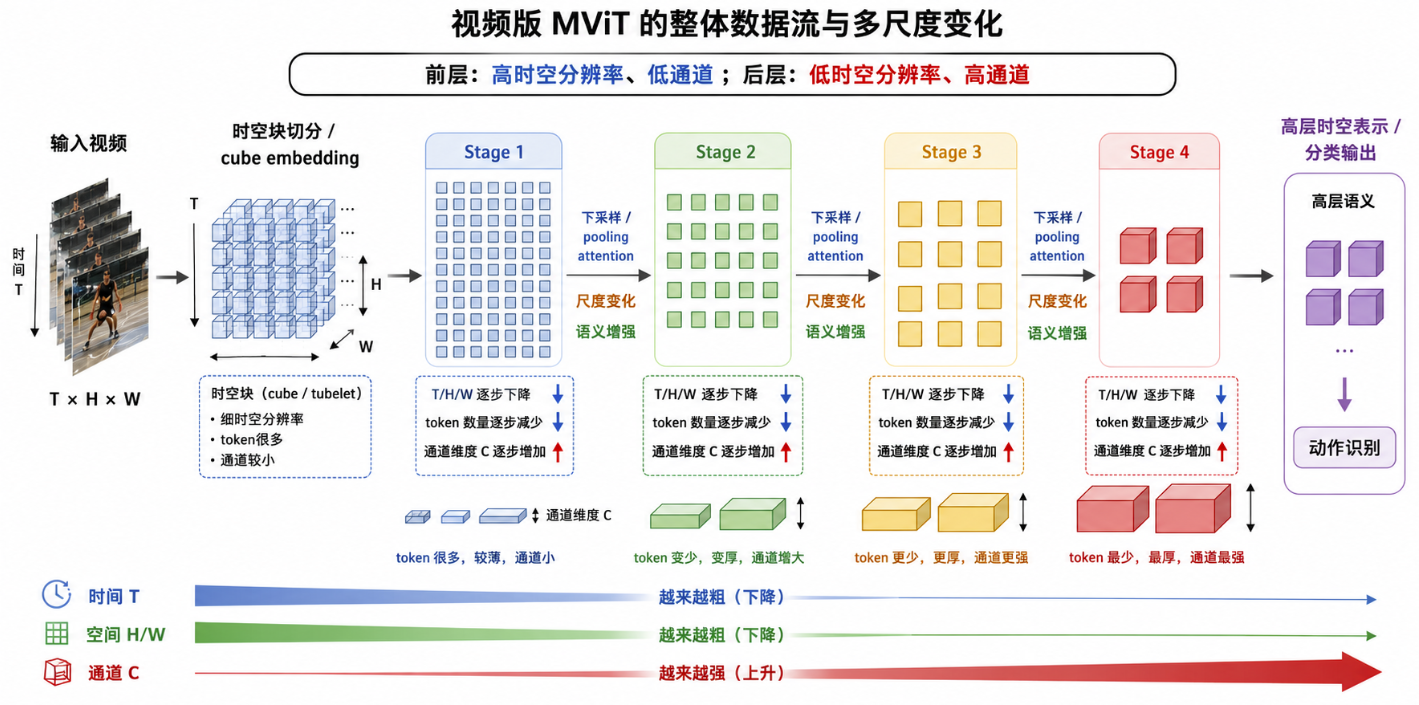

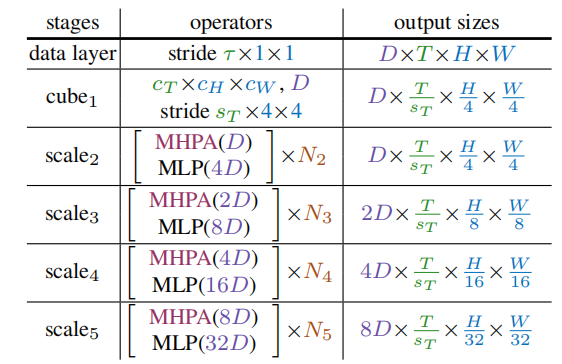

### 1.3 MViT和ViT的关键区别

前面已经看过 MViT 的多尺度定义和整体数据流了，这里不再重复展开，只把它和 ViT 的区别收束成几个最关键的点。

第一，**建模对象不同。**

ViT 主要面向图像，把二维 patch 变成 token；MViT 最初面向视频，把带有时间跨度的时空块变成 token。两者都在做 token 化，但 MViT 从一开始面对的就是更稠密的 `T × H × W` 时空信号。

第二，**主干结构不同。**

ViT 更接近单尺度结构：输入切成 token 以后，后面很多层基本都在固定分辨率、固定通道维度上建模。MViT 则是多尺度结构：

- 时空分辨率逐步下降
- token 数量逐步减少
- 通道维度逐步增加

所以，ViT 更像是在一个固定尺度上反复加工 token；MViT 更像是在多个尺度之间逐步重组 token 表示。

第三，**注意力模块不同。**

ViT 用的是标准多头注意力，`Q、K、V` 的序列长度通常不变。MViT 用的是 `MHPA`，也就是带池化的多头注意力。这样一来，注意力不只负责信息交互，还直接参与时空下采样。

这里可以把两者的区别记成一句话：

- ViT 的注意力主要负责“让 token 彼此交互”
- MViT 的注意力既负责“让 token 彼此交互”，也负责“让 token 改变尺度”

第四，**效率和归纳方式不同。**

视频里的 token 数远大于图像，如果一直在高分辨率上做注意力，代价会很高。MViT 的做法是前面保留更细的时空信息，后面逐步下采样并提升通道能力。这样既更贴合视频理解的规律，也更容易控制计算量。

因此，如果把这一节再压成一句总结，可以这样记：

**ViT 的重点是“把视觉输入变成 token 后交给 Transformer”；MViT 的重点是“让这些 token 在 Transformer 内部继续按多尺度方式演化”。**
